# Identificação de ansiedade

In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [ ]:
!pip install Unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import random
import numpy as np
import torch

# Loading data

In [ ]:
url = 'https://docs.google.com/spreadsheets/d/1eLljmEHLfI01dqB8Li3bqPDP86wJCm9L/edit?usp=sharing&ouid=117999606608884179014&rtpof=true&sd=true'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

data_set = pd.read_excel(read_url, index_col=False)

condition = [
    data_set["rotulo_humano"] == "sem_sintoma", # 0
    data_set["rotulo_humano"] == "sintoma" # 1
]

values = [0, 1]

data_set["classification"] = np.select(condition, values)

data_set

,Texto,rotulo_humano,rotulo_vader,interpretacao_rotulo_vader,vader_metricas,classification
0,"Primeiro dia no trabalho novo, ansiedade lá em...",sintoma,negativo,sintoma,"{'neg': 0.338, 'neu': 0.662, 'pos': 0.0, 'comp...",1
1,"Por algum motivo, mesmo sendo 102% virgem eu e...",sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
2,Só queria me entupir de doce pra ver se essa a...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
3,odeio ter pensamentos automaticos contaminados...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
4,eu sinto que nos braços dela tem a cura da min...,sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",1
...,...,...,...,...,...,...
95,"Pow kkkkkk nem querendo defender, mas não dá p...",sem_sintoma,negativo,sintoma,"{'neg': 0.06, 'neu': 0.902, 'pos': 0.038, 'com...",0
96,Horrível ter que dormir e tirar as roupas do v...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0
97,ai que bom que é normal então tava com medo de...,sem_sintoma,negativo,sintoma,"{'neg': 0.177, 'neu': 0.823, 'pos': 0.0, 'comp...",0
98,Garfield é ALFA mesmo sendo gordo pois ele tem...,sem_sintoma,neutro,sem_sintoma,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0


# Unsloth

In [ ]:
from unsloth import FastLanguageModel

fourbit_models = [
    "unsloth/Qwen3-1.7B-unsloth-bnb-4bit", # Qwen 14B 2x faster
    "unsloth/Qwen3-4B-unsloth-bnb-4bit",
    "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    "unsloth/Qwen3-14B-unsloth-bnb-4bit",
    "unsloth/Qwen3-32B-unsloth-bnb-4bit",
    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/Phi-4",
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/orpheus-3b-0.1-ft-unsloth-bnb-4bit" # [NEW] We support TTS models!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    max_seq_length = 2048,   # Context length - can be longer, but uses more memory
    load_in_4bit = True,     # 4bit uses much less memory
    load_in_8bit = False,    # A bit more accurate, uses 2x memory
    full_finetuning = False, # We have full finetuning now!
    # token = "hf_...",      # use one if using gated models
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


    PyTorch 2.6.0+cu124 with CUDA 1204 (you have 2.8.0+cu126)
    Python  3.12.9 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Switching to PyTorch attention since your Xformers is broken.

Unsloth: Xformers was not installed correctly.
Please install xformers separately first.
Then confirm if it's correctly installed by running:
python -m xformers.info

Longer error message:
xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.6.0+cu124 with CUDA 1204 (you have 2.8.0+cu126)
    Python  3.12.9 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.10.11: Fast Qwen3 patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32,           # Choose any number > 0! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 32,  # Best to choose alpha = rank or rank*2
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,   # We support rank stabilized LoRA
    loftq_config = None,  # And LoftQ
)

Unsloth 2025.10.11 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


<a name="Inference"></a>
### **Inference**
De acordo com a equipe `Qwen-3`, as configurações recomendadas para inferência de raciocínio são `temperature = 0.6, top_p = 0.95, top_k = 20`

Para inferência baseada em bate-papo normal, `temperature = 0.7, top_p = 0.8, top_k = 20`

In [ ]:
from tqdm import tqdm
import torch

answers_llm = {
    "text": data_set["Texto"].tolist(),
    "target": data_set["classification"].tolist(),
    "predicted": []
}

sentences = answers_llm["text"]

FastLanguageModel.for_inference(model)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

batch_size = 16
for i in tqdm(range(0, len(sentences), batch_size)):
    batch = sentences[i:i+batch_size]

    prompts = [
        f"""
        Você é um modelo de IA treinado para classificar frases quanto à ansiedade.

        Regras:
        - Se a frase indicar ansiedade ou depressão, retorne exatamente "1".
        - Se a frase não indicar ansiedade ou depressão, retorne exatamente "0".
        - Não adicione explicações.

        Frase: "{sentence}"
        """
        for sentence in batch
    ]

    texts = [
        tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}],
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=True,
        )
        for prompt in prompts
    ]

    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=16,
            temperature=0.6,
            top_p=0.95,
            top_k=20,
        )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

    preds = []
    for text in decoded:
        if "0" in text:
            preds.append("0")
        elif "1" in text:
            preds.append("1")
        else:
            preds.append("")

    answers_llm["predicted"].extend(preds)


100%|██████████| 7/7 [01:04<00:00,  9.26s/it]


In [ ]:
# from google.colab import files

df = pd.DataFrame(answers_llm)
df.to_csv('/content/drive/MyDrive/Notebooks/Others/Outputs/respostas_qwen3.csv', index=False)

# files.download('respostas_qwen3.xlsx')

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

y_true = answers_llm["target"]
y_pred = answers_llm["predicted"]

y_true = [int(x) for x in y_true]
y_pred = [int(x.strip()) if x.strip() in ['0', '1'] else 0 for x in y_pred]

acc = accuracy_score(y_true, y_pred)
print(f"Acurácia: {acc:.4f}")

print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=["Sem ansiedade (0)", "Com ansiedade (1)"]))


Acurácia: 0.5000

Relatório de Classificação:
                   precision    recall  f1-score   support

Sem ansiedade (0)       0.50      1.00      0.67        50
Com ansiedade (1)       0.00      0.00      0.00        50

         accuracy                           0.50       100
        macro avg       0.25      0.50      0.33       100
     weighted avg       0.25      0.50      0.33       100



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_preds, y_true, labels=None):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

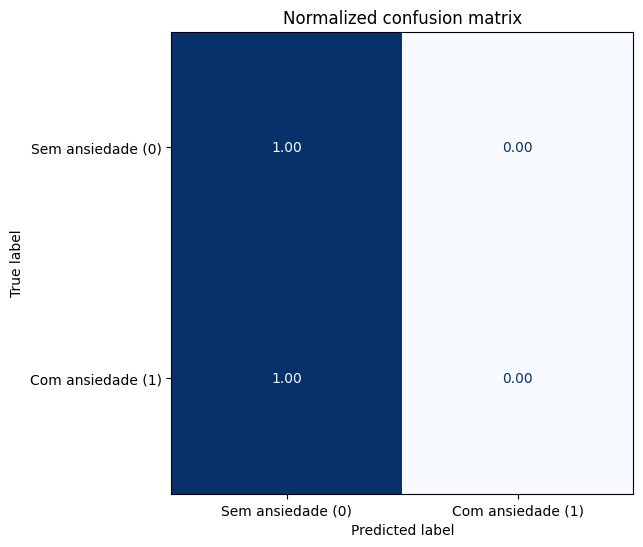

In [ ]:
plot_confusion_matrix(y_pred, y_true, labels=["Sem ansiedade (0)", "Com ansiedade (1)"])